Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-02-13 (+13 weeks)


/home/de-schrijvers/projects/germany_gnn/src/dataloading/epidataloader.py:209: UserWarning: 12 rows with missing tokenized IDs will be dropped from 'shapedata'. Dropped original IDs: ['11012' '11004' '11009' '11003' '11008' '11011' '11010' '11005' '11006'
 '11001' '11002' '11007']
  warnings.warn(


Epoch 1 train loss: 0.8466, val loss: 0.5465 (patience: 1/20)
Epoch 2 train loss: 0.8605, val loss: 0.5466 (patience: 2/20)
Epoch 3 train loss: 0.8602, val loss: 0.5469 (patience: 3/20)
Epoch 4 train loss: 0.8600, val loss: 0.5470 (patience: 4/20)
Epoch 5 train loss: 0.8599, val loss: 0.5467 (patience: 5/20)
Epoch 6 train loss: 0.8599, val loss: 0.5466 (patience: 6/20)
Epoch 7 train loss: 0.8588, val loss: 0.5467 (patience: 7/20)
Epoch 8 train loss: 0.8584, val loss: 0.5470 (patience: 8/20)
Epoch 9 train loss: 0.8592, val loss: 0.5470 (patience: 9/20)
Epoch 10 train loss: 0.8585, val loss: 0.5468 (patience: 10/20)
Epoch 11 train loss: 0.8591, val loss: 0.5468 (patience: 11/20)
Epoch 12 train loss: 0.8587, val loss: 0.5468 (patience: 12/20)
Epoch 13 train loss: 0.8586, val loss: 0.5468 (patience: 13/20)
Epoch 14 train loss: 0.8585, val loss: 0.5470 (patience: 14/20)
Epoch 15 train loss: 0.8581, val loss: 0.5469 (patience: 15/20)
Epoch 16 train loss: 0.8567, val loss: 0.5470 (patience: 1

(<Figure size 1600x1000 with 2 Axes>,
 array([<Axes: title={'center': 'National aggregation of incidence'}, ylabel='incidence'>,
        <Axes: title={'center': 'predictions node: 26'}, ylabel='incidence'>],
       dtype=object))

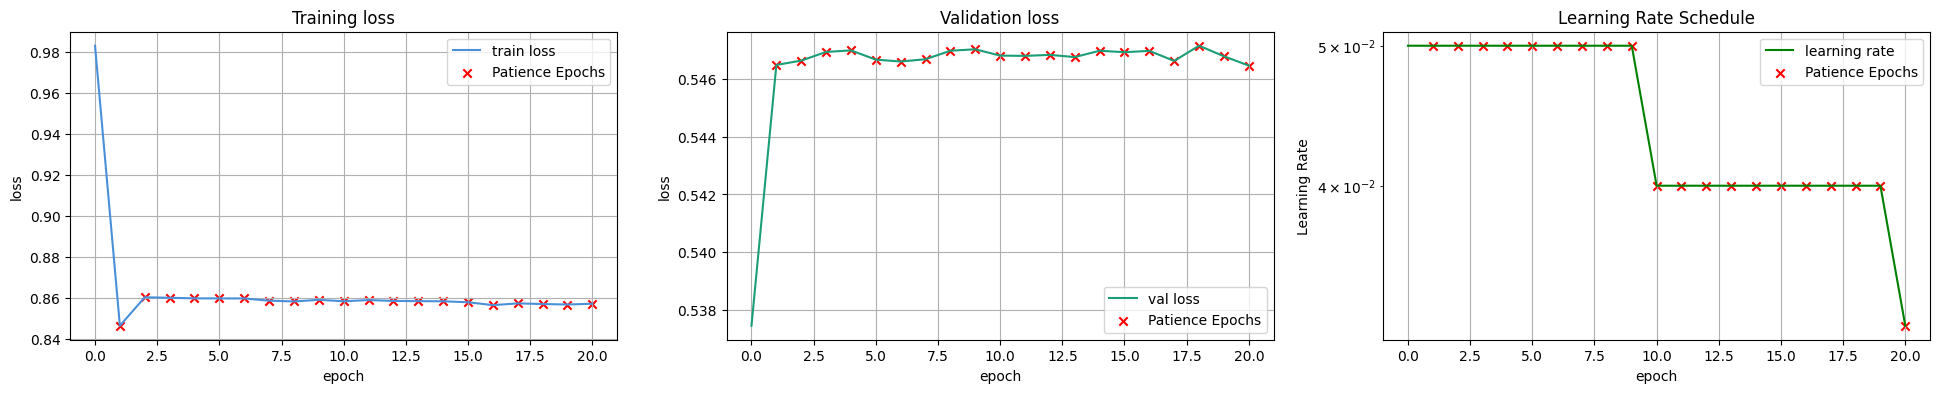

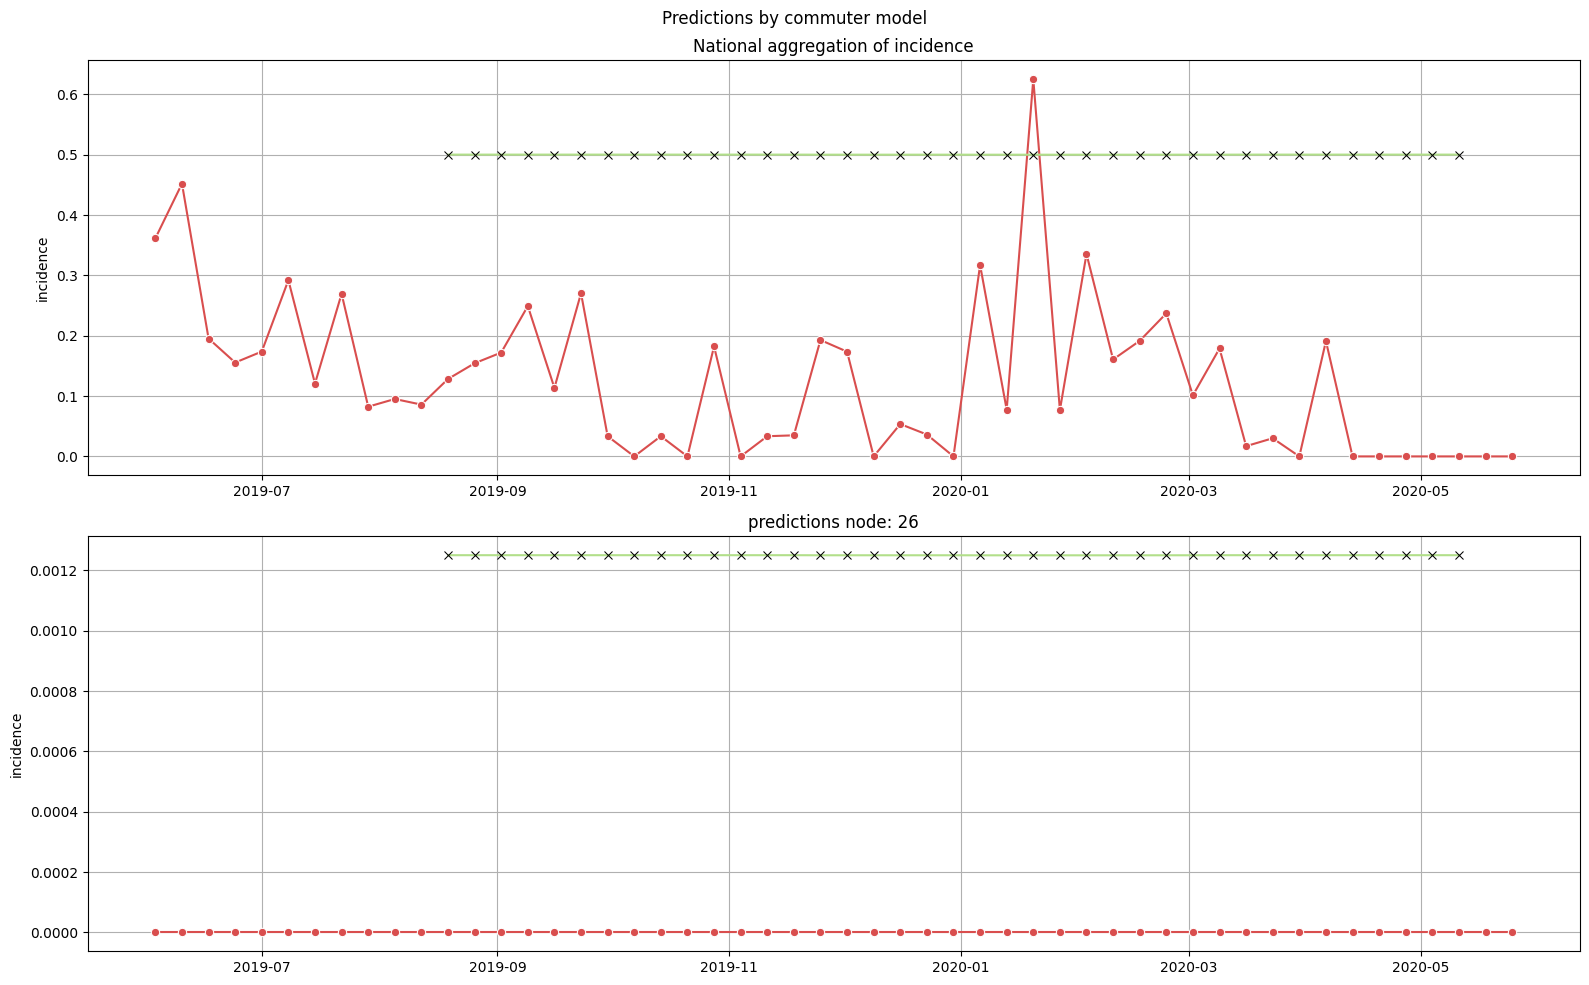

In [9]:
from src.dataloading.gnndataloader import GNNDataLoader
from src.utils import get_data_env
from src.models.spatiotemporal_baseline import TGCNModel
disease_name    = 'measles'
model           = 'tgcn'
nuts_level      = 'nuts3'
min_date            ='2006-05-15'
max_date            = '2020-06-01'
split_trainval = '2018-06-01'
split_valtest  = '2019-06-01'
split_berlin = False


n_epochs = 100
lr       = 0.05
min_delta = 0.0001
loss = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'step',
    "scheduler_kwargs"  : {'step_size': 10, 'gamma': 0.8},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

epidata_nuts3 = GNNDataLoader('measles', get_data_env(), nuts_level='nuts3', min_date=min_date,max_date=max_date, include_population=False, horizon_size = 1, horizon_leadtime = 1, sequence_length=12, split_berlin=split_berlin)
epidata_nuts3.add_time_features()
epidata_nuts3.log_transform_target()
epidata_nuts3.set_splits(split_trainval, split_valtest)
epidata_nuts3.normalize()
epidata_nuts3.add_lagged_features(lags = 1)
epidata_nuts3.finalize()
epidata_nuts3.retrieve_graph('commuter_t1500_selfmean_rowwise')
epidata_nuts3.construct_dataloaders()

mainmodel = TGCNModel(epidata_nuts3, name = 'commuter model')
mainmodel.set_model_hparams()
mainmodel.set_global_hparams(**global_hparams)
mainmodel.train(verbose = 2, dataloader_snapshot=False, show_loss= True)
mainmodel.forecast('test')
mainmodel.show_forecasts('test', 26)






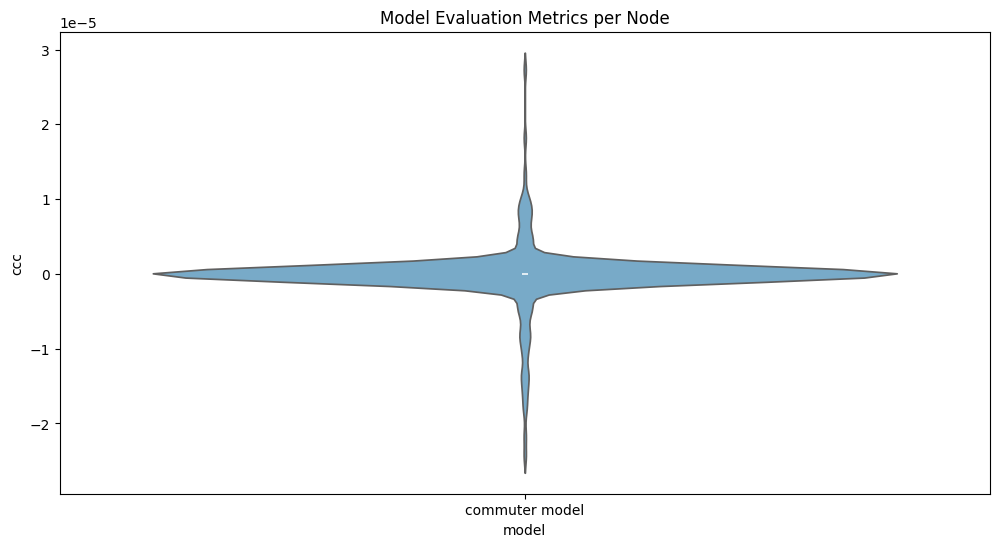

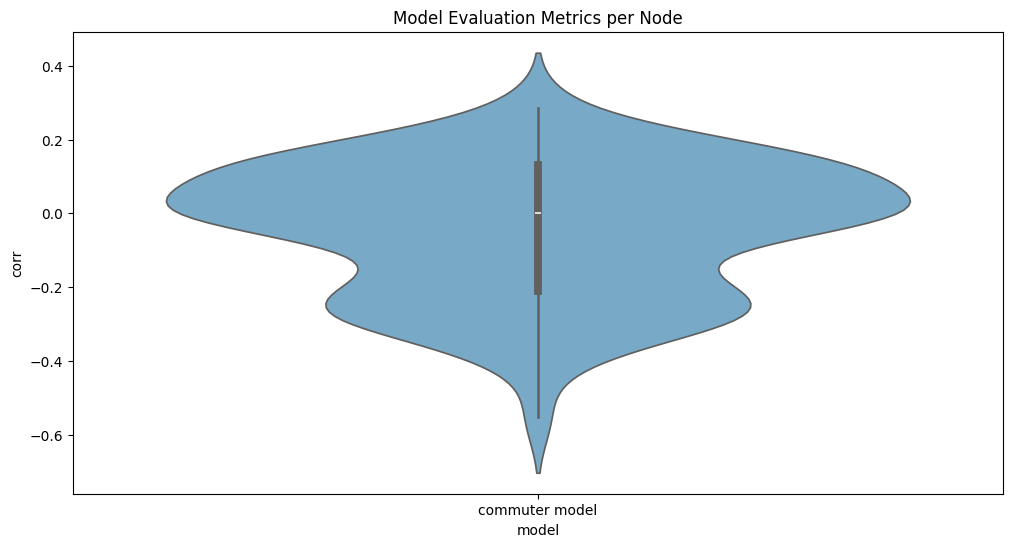

In [10]:
from src.metrics.evaluator import Evaluator
ev = Evaluator(models = [mainmodel])
ev.add_evaluation()
ev.plot_metric(metric = 'ccc')
ev.plot_metric(metric = 'corr')